МОДЕЛЬ RANDOM FOREST ДЛЯ ПРОГНОЗА СКР НА 2019 ГОД

1. Загрузка данных...

2. Стандартизация названий регионов...
   Уникальных регионов после очистки: 85
   Годы в данных: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
   ✓ Данные за 2019 год присутствуют

3. Диагностика данных:
   Размер данных: (850, 14)
   Период данных: 2014-2023
   Количество регионов: 85

4. Обучение модели на данных до 2018 года...
   Обучение модели...
Исходные данные: 2014-2023, 850 строк
Данные до обработки NaN: 850 строк
Данные после обработки NaN: 850 строк
Годы после обработки: 2014-2023
Данные за период: 2014-2023
Используется 26 признаков
Размер train: (595, 26), test: (255, 26)
Период обучения: 2014-2023
Период тестирования: 2019-2021
Обучение модели на расширенных данных...

МЕТРИКИ КАЧЕСТВА Random Forest ДЛЯ СКР
RMSE: 0.0324
MAE: 0.0253
R²: 0.9865
Средний СКР в тесте: 1.5242
Относительная 

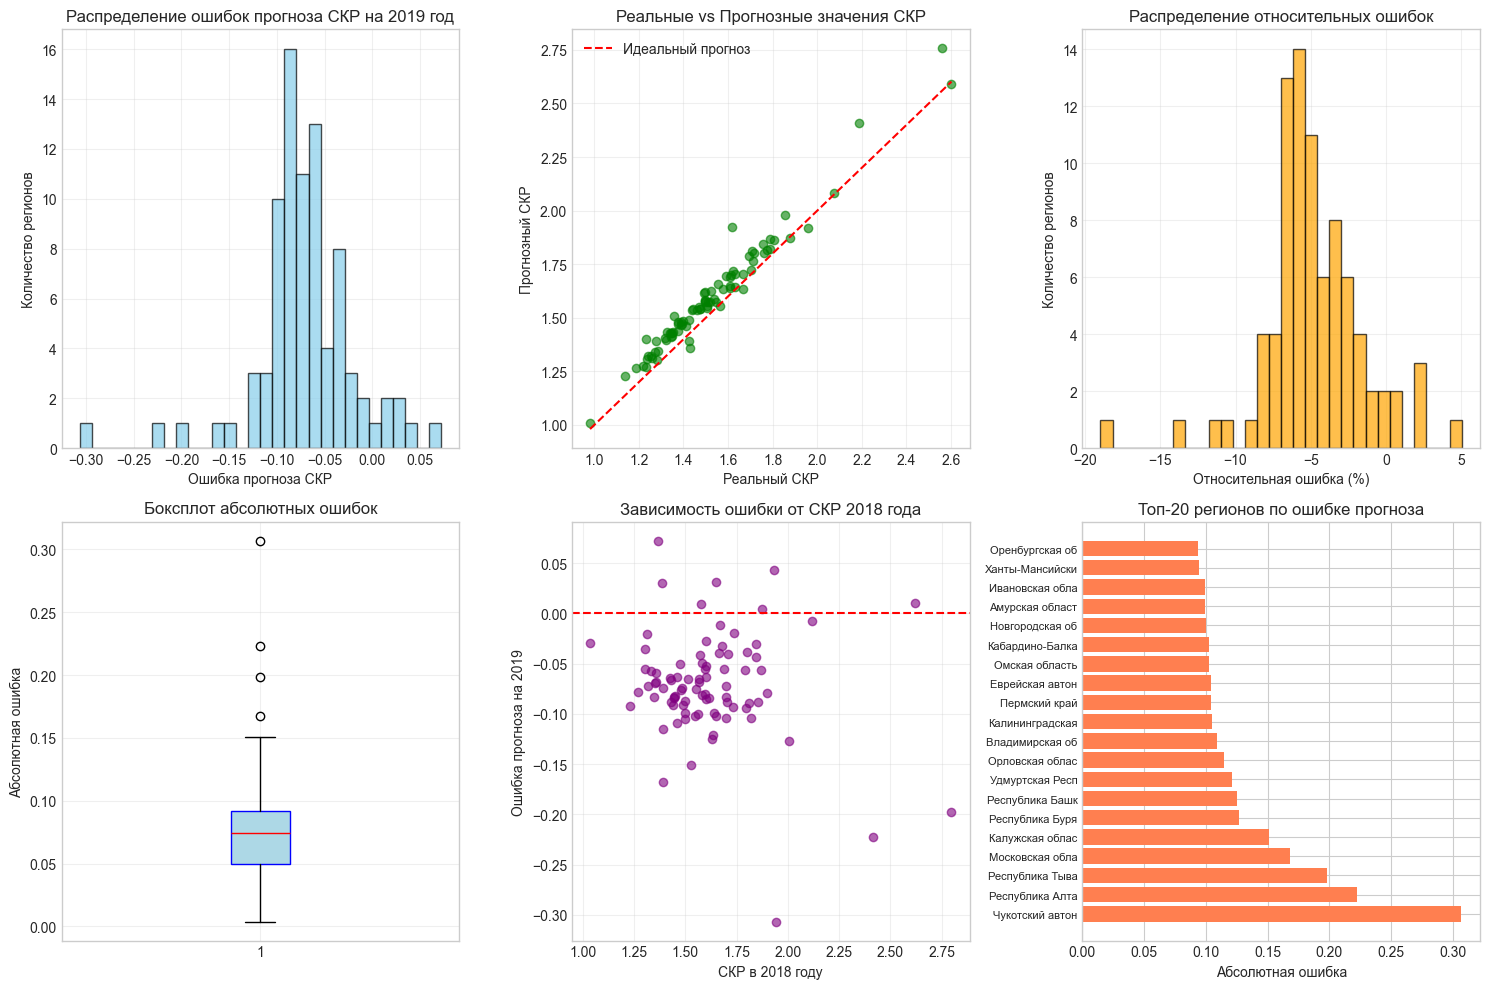


✓ График анализа сравнения сохранен как 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\Random Forest\rf_skr_comparison_analysis_2019.png'

8. Создание упрощенных графиков...


<Figure size 640x480 with 0 Axes>

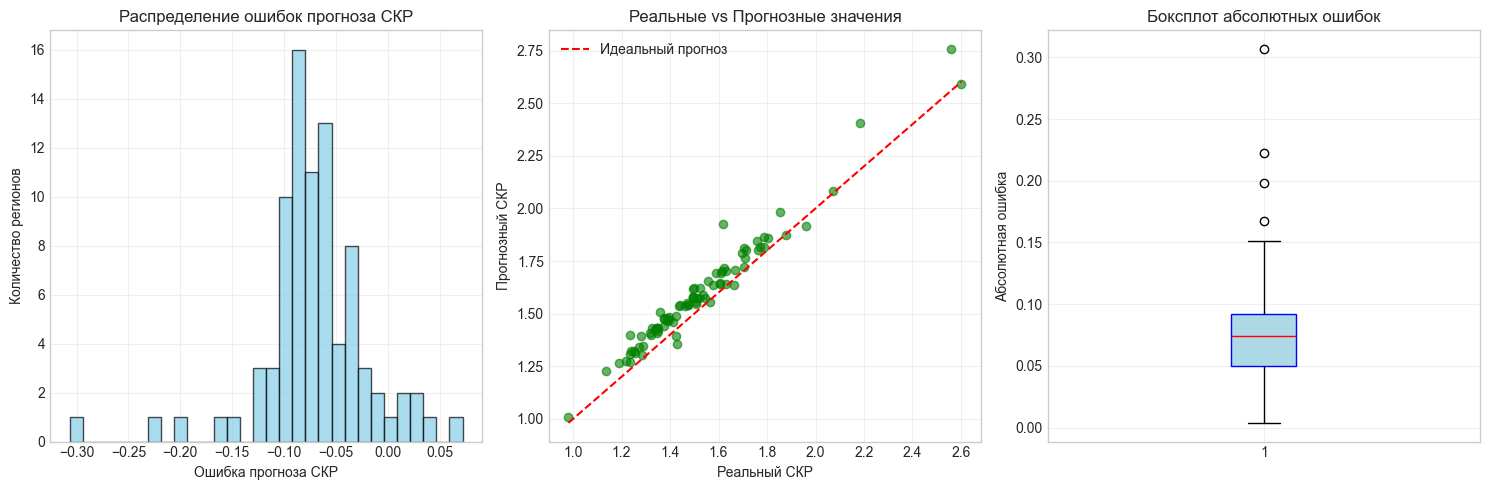

✓ Упрощенный график анализа сохранен как 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\Random Forest\rf_skr_comparison_simple_2019.png'

9. Создание графиков распределения ошибок...


<Figure size 640x480 with 0 Axes>

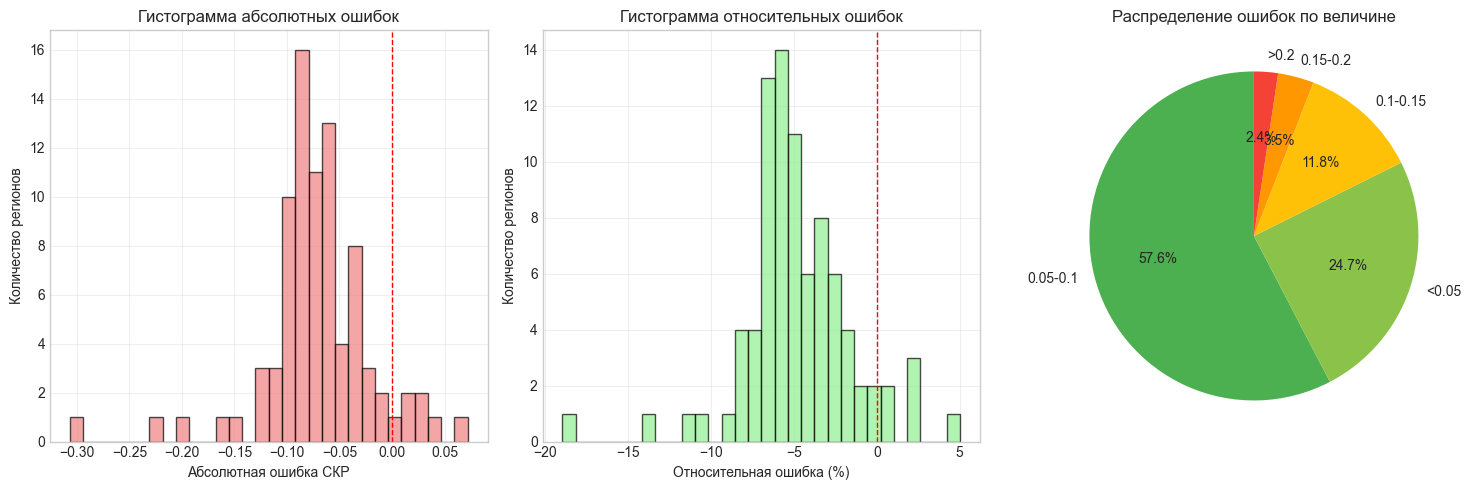

✓ График распределения ошибок сохранен как 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\Random Forest\rf_skr_error_distribution_2019.png'

10. Создание детального графика сравнения...


<Figure size 640x480 with 0 Axes>

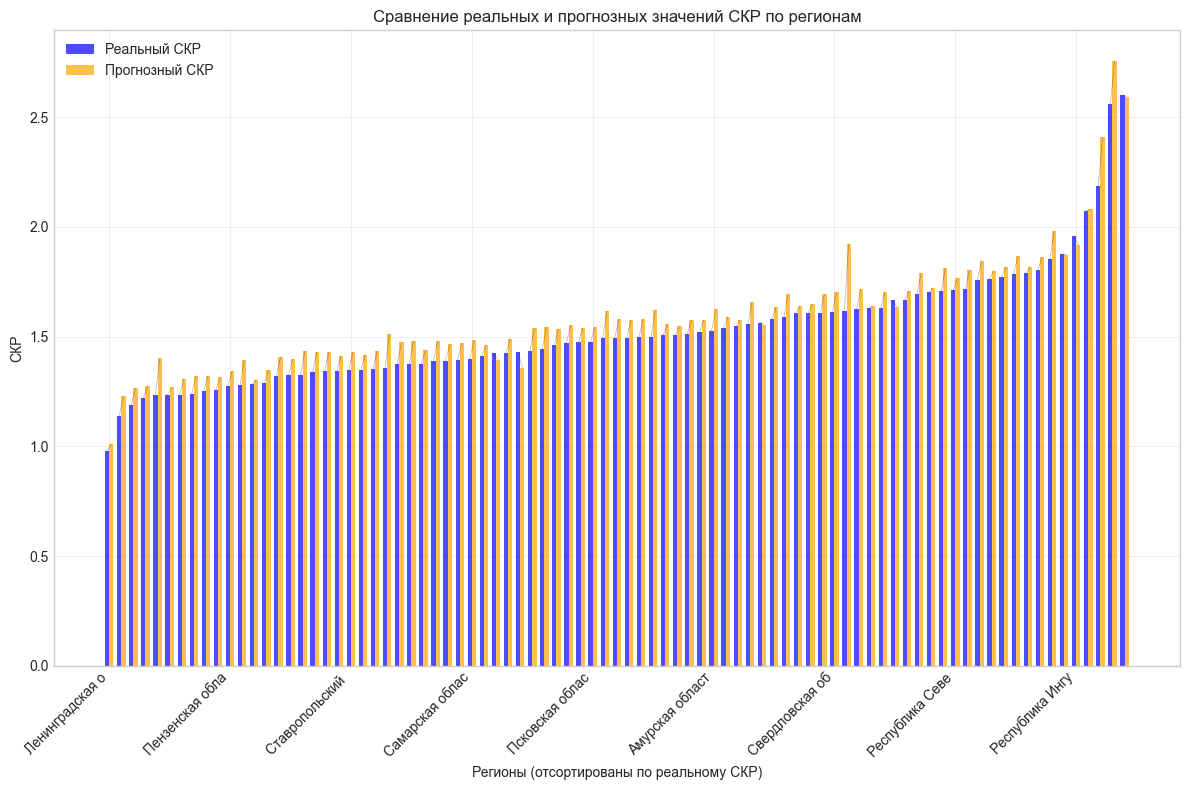

✓ Детальный график сравнения сохранен как 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\Random Forest\rf_skr_prediction_vs_actual_detail_2019.png'

11. Подготовка финального вывода...

   ✓ Финальный файл с прогнозами и сравнением сохранен как 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\Random Forest\rf_skr_predictions_2019_comparison.xlsx'
   ✓ Сводная статистика сохранена как 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\Random Forest\rf_skr_prediction_summary_2019.csv'

ПРИМЕРЫ РЕЗУЛЬТАТОВ:
----------------------------------------------------------------------

Лучшие прогнозы:
  Сахалинская область       | Ошибка: 0.0039
  Ненецкий автономный округ | Ошибка: 0.0077
  Хабаровский край          | Ошибка: 0.0091
  Чеченская Республика      | Ошибка: 0.0097
  Республика Коми           | Ошибка: 0.0115

Худшие прогнозы:
  Чукотский автономн

<Figure size 640x480 with 0 Axes>

In [1]:
# Random Forest для СКР с данными за 2014-2023
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os
import matplotlib.pyplot as plt  # ДОБАВЛЕНО: импорт matplotlib
import warnings
warnings.filterwarnings('ignore')

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

output_dir = current_dir 

def standardize_region_names(df):
    """Стандартизация названий регионов"""
    df_clean = df.copy()
    
    # Создаем словарь замен
    replacements = {
        'Ненецкий авт.округ': 'Ненецкий автономный округ',
        'Hенецкий авт.округ': 'Ненецкий автономный округ',
        '  Ненецкий автономный округ': 'Ненецкий автономный округ',
        
        'Ямало-Ненецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        'Ямало-Hенецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        '  Ямало-Ненецкий автономный округ': 'Ямало-Ненецкий автономный округ',
        
        'Ханты-Мансийский авт.округ-Югра': 'Ханты-Мансийский автономный округ - Югра',
        '  Ханты-Мансийский автономный округ - Югра': 'Ханты-Мансийский автономный округ - Югра',
        
        'Республика Татарстан(Татарстан)': 'Республика Татарстан',
        'Чувашская Республика(Чувашия)': 'Чувашская Республика',
        'Республика Северная Осетия- Алания': 'Республика Северная Осетия-Алания',
        
        'Oмская область': 'Омская область',
        'Hижегородская область': 'Нижегородская область',
        
        'г. Севастополь': 'г.Севастополь',
        'г.Москва': 'г.Москва',
        'г.Санкт-Петербург': 'г.Санкт-Петербург',
        
        'Чукотский авт.округ': 'Чукотский автономный округ',
        'Чукотский автономный округ': 'Чукотский автономный округ'
    }
    
    # Применяем замены
    df_clean['Регион'] = df_clean['Регион'].replace(replacements)
    
    return df_clean

class SKRForecaster:
    def __init__(self, n_estimators=100, random_state=42):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            random_state=random_state,
            max_depth=10,
            min_samples_split=5,
            n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.feature_names = []
        self.is_fitted = False
        self.last_known_data = None
        self.first_year = None
        self.comparison_results = None  # ДОБАВЛЕНО: для хранения результатов сравнения
        
    def clean_numeric_columns(self, df):
        """
        Очистка числовых колонок
        """
        df = df.copy()
        
        numeric_columns = [col for col in df.columns if col not in ['Регион', 'Год', 'СКР']]
        
        for col in numeric_columns:
            if df[col].dtype == 'object':
                df[col] = (df[col]
                          .astype(str)
                          .str.replace('\xa0', '')
                          .str.replace(' ', '')
                          .str.replace(',', '.')
                          .str.replace('−', '-')
                          .str.replace('–', '-')
                          )
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        if 'СКР' in df.columns:
            df['СКР'] = pd.to_numeric(df['СКР'], errors='coerce')
        
        return df
        
    def prepare_features(self, df, is_training=True):
        """
        Подготовка признаков с данными за 2014-2023
        """
        df = df.copy().sort_values(['Регион', 'Год'])
        
        # Определяем первый год для расчета тренда
        if self.first_year is None:
            self.first_year = df['Год'].min()
        
        print(f"Исходные данные: {df['Год'].min()}-{df['Год'].max()}, {len(df)} строк")
        
        # Создание лаговых признаков
        if is_training or df['Год'].min() < 2024:
            df['lag1_СКР'] = df.groupby('Регион')['СКР'].shift(1)
            df['lag2_СКР'] = df.groupby('Регион')['СКР'].shift(2)
            df['lag1_Браков'] = df.groupby('Регион')['Браков'].shift(1)
            df['lag1_Разводов'] = df.groupby('Регион')['Разводов'].shift(1)
            df['lag1_Число родившихся'] = df.groupby('Регион')['Число родившихся'].shift(1)
            
            # Скользящие средние с min_periods=1 чтобы сохранить больше данных
            df['СКР_MA2'] = df.groupby('Регион')['СКР'].transform(lambda x: x.rolling(2, min_periods=1).mean())
            df['СКР_MA3'] = df.groupby('Регион')['СКР'].transform(lambda x: x.rolling(3, min_periods=1).mean())
        
        # Создание тренда времени
        df['year_trend'] = df['Год'] - self.first_year
        df['год_от_начала'] = df['Год'] - self.first_year
        
        # Создание производных показателей
        df['Браков_на_1000'] = df['Браков'] / df['Численность населения'] * 1000
        df['Разводов_на_1000'] = df['Разводов'] / df['Численность населения'] * 1000
        df['Родившихся_на_1000'] = df['Число родившихся'] / df['Численность населения'] * 1000
        df['Преступлений_на_1000'] = df['Кол-во преступлений'] / df['Численность населения'] * 1000
        
        # Экономические индексы
        df['Социально_экономический_индекс'] = (
            df['Средняя ЗП'] / df['Величина прожиточного минимума'] - 
            (df['Уровень бедности'] / 100)
        )
        
        # Относительные изменения
        df['изменение_населения'] = df.groupby('Регион')['Численность населения'].pct_change()
        df['изменение_ВРП'] = df.groupby('Регион')['Валовой региональный продукт на душу населения (ОКВЭД 2)'].pct_change()
        
        if is_training:
            print(f"Данные до обработки NaN: {len(df)} строк")
            
            # Заполняем числовые колонки медианами по регионам
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if col not in ['Год']:  # не заполняем год
                    # Заполняем медианами по регионам
                    df[col] = df.groupby('Регион')[col].transform(
                        lambda x: x.fillna(x.median()) if not x.isnull().all() else x
                    )
            
            # Если все еще есть NaN, заполняем общими медианами
            df = df.fillna(df.median(numeric_only=True))
            
            print(f"Данные после обработки NaN: {len(df)} строк")
            print(f"Годы после обработки: {df['Год'].min()}-{df['Год'].max()}")
        
        return df
    
    def train_test_split_temporal(self, df, test_years=[2019, 2020, 2021]):
        """
        Разделение на train/test по времени
        """
        train_mask = ~df['Год'].isin(test_years)
        test_mask = df['Год'].isin(test_years)
        
        X_train = df[train_mask][self.feature_names]
        X_test = df[test_mask][self.feature_names]
        y_train = df[train_mask]['СКР']
        y_test = df[test_mask]['СКР']
        
        return X_train, X_test, y_train, y_test, train_mask, test_mask
    
    def fit(self, df, test_years=[2019, 2020, 2021]):
        """
        Обучение модели на расширенных данных
        """
        # Очистка и подготовка данных
        df_clean = self.clean_numeric_columns(df)
        df_processed = self.prepare_features(df_clean, is_training=True)
        
        print(f"Данные за период: {df_processed['Год'].min()}-{df_processed['Год'].max()}")
        
        # Сохраняем последние известные данные для прогноза (2018 год для предсказания 2019)
        self.last_known_data = df_processed[df_processed['Год'] == 2018].copy()
        
        # Определение признаков
        self.feature_names = [
            # Демографические
            'Численность населения', 
            'Число родившихся',
            'Браков', 
            'Разводов',
            
            # Социально-экономические
            'Кол-во преступлений', 
            'Уровень безработицы', 
            'Уровень бедности', 
            'Величина прожиточного минимума',
            'Валовой региональный продукт на душу населения (ОКВЭД 2)',
            'Средняя ЗП',
            
            # Лаговые признаки
            'lag1_СКР', 
            'lag2_СКР',
            'lag1_Браков', 
            'lag1_Разводов',
            'lag1_Число родившихся',
            
            # Скользящие средние
            'СКР_MA2',
            'СКР_MA3',
            
            # Тренд и время
            'year_trend',
            'год_от_начала',
            
            # Производные показатели
            'Браков_на_1000', 
            'Разводов_на_1000',
            'Родившихся_на_1000',
            'Преступлений_на_1000',
            'Социально_экономический_индекс',
            'изменение_населения',
            'изменение_ВРП'
        ]
        
        # Убираем признаки, которых нет в данных
        available_features = [f for f in self.feature_names if f in df_processed.columns]
        self.feature_names = available_features
        
        print(f"Используется {len(self.feature_names)} признаков")
        
        # Разделение на train/test
        X_train, X_test, y_train, y_test, train_mask, test_mask = self.train_test_split_temporal(df_processed, test_years)
        
        print(f"Размер train: {X_train.shape}, test: {X_test.shape}")
        print(f"Период обучения: {df_processed[train_mask]['Год'].min()}-{df_processed[train_mask]['Год'].max()}")
        print(f"Период тестирования: {df_processed[test_mask]['Год'].min()}-{df_processed[test_mask]['Год'].max()}")
        
        # Масштабирование признаков
        scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'СКР_MA', 'изменение_'))]
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        
        X_train_scaled[scale_features] = self.scaler.fit_transform(X_train[scale_features])
        X_test_scaled[scale_features] = self.scaler.transform(X_test[scale_features])
        
        # Обучение модели
        print("Обучение модели на расширенных данных...")
        self.model.fit(X_train_scaled, y_train)
        self.is_fitted = True
        
        # Предсказание на тесте
        y_pred = self.model.predict(X_test_scaled)
        
        # Метрики качества
        self.calculate_metrics(y_test, y_pred)
        
        # Дополнительная валидация
        self.cross_validation(X_train_scaled, y_train)
        
        # Сохранение результатов
        self.results = {
            'X_train': X_train_scaled, 'X_test': X_test_scaled,
            'y_train': y_train, 'y_test': y_test, 'y_pred': y_pred,
            'df_processed': df_processed,
            'test_years': test_years
        }
        
        return self
    
    def calculate_metrics(self, y_true, y_pred):
        """
        Расчет метрик качества
        """
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        
        print("\n" + "="*50)
        print("МЕТРИКИ КАЧЕСТВА Random Forest ДЛЯ СКР")
        print("="*50)
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"Средний СКР в тесте: {y_true.mean():.4f}")
        print(f"Относительная ошибка: {rmse/y_true.mean()*100:.2f}%")
        
        # Дополнительные метрики
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        max_error = np.max(np.abs(y_true - y_pred))
        median_error = np.median(np.abs(y_true - y_pred))
        print(f"MAPE: {mape:.2f}%")
        print(f"Максимальная ошибка: {max_error:.4f}")
        print(f"Медианная ошибка: {median_error:.4f}")
        
        self.metrics = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape, 'MaxError': max_error, 'MedianError': median_error}
    
    def cross_validation(self, X_train, y_train, cv=5):
        """
        Кросс-валидация для оценки устойчивости модели
        """
        print("\nКросс-валидация (RMSE):")
        scores = cross_val_score(self.model, X_train, y_train, 
                               scoring='neg_mean_squared_error', cv=cv)
        rmse_scores = np.sqrt(-scores)
        print(f"Среднее: {rmse_scores.mean():.4f} (+/- {rmse_scores.std() * 2:.4f})")
    
    # ДОБАВЛЕННЫЕ ФУНКЦИИ ДЛЯ АНАЛИЗА И ГРАФИКОВ
    
    def analyze_comparison_results(self, comparison_df):
        """
        Детальный анализ результатов сравнения прогноза с реальными данными
        """
        print(f"\n{'='*70}")
        print("ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ СРАВНЕНИЯ СКР")
        print(f"{'='*70}")
        
        print(f"\nОБЩАЯ СТАТИСТИКА:")
        print(f"Всего регионов: {len(comparison_df)}")
        print(f"Средний реальный СКР: {comparison_df['СКР_реальный'].mean():.4f}")
        print(f"Средний прогнозный СКР: {comparison_df['СКР_прогноз'].mean():.4f}")
        print(f"Средняя абсолютная ошибка: {comparison_df['Ошибка_абсолютная_abs'].mean():.4f}")
        print(f"Медианная абсолютная ошибка: {comparison_df['Ошибка_абсолютная_abs'].median():.4f}")
        print(f"Максимальная ошибка: {comparison_df['Ошибка_абсолютная_abs'].max():.4f}")
        print(f"Минимальная ошибка: {comparison_df['Ошибка_абсолютная_abs'].min():.4f}")
        
        # Статистика по ошибкам
        print(f"\nСТАТИСТИКА ПО ОШИБКАМ:")
        error_positive = (comparison_df['Ошибка_абсолютная'] > 0).sum()
        error_negative = (comparison_df['Ошибка_абсолютная'] < 0).sum()
        print(f"Прогноз занижен (реальный > прогноз): {error_positive} регионов")
        print(f"Прогноз завышен (реальный < прогноз): {error_negative} регионов")
        
        # Топ регионов по точности прогноза
        print(f"\nТОП-10 РЕГИОНОВ С НАИБОЛЕЕ ТОЧНЫМ ПРОГНОЗОМ:")
        top_accurate = comparison_df.nsmallest(10, 'Ошибка_абсолютная_abs')
        for i, row in top_accurate.iterrows():
            print(f"  {row['Регион'][:30]:<30} | Ошибка: {row['Ошибка_абсолютная_abs']:.4f} | "
                  f"Реальный: {row['СКР_реальный']:.4f} | Прогноз: {row['СКР_прогноз']:.4f}")
        
        # Топ регионов с наибольшей ошибкой
        print(f"\nТОП-10 РЕГИОНОВ С НАИБОЛЬШЕЙ ОШИБКОЙ:")
        top_error = comparison_df.nlargest(10, 'Ошибка_абсолютная_abs')
        for i, row in top_error.iterrows():
            print(f"  {row['Регион'][:30]:<30} | Ошибка: {row['Ошибка_абсолютная_abs']:.4f} | "
                  f"Реальный: {row['СКР_реальный']:.4f} | Прогноз: {row['СКР_прогноз']:.4f}")
        
        # Анализ распределения ошибок
        error_quartiles = np.percentile(comparison_df['Ошибка_абсолютная_abs'], [25, 50, 75, 90, 95])
        print(f"\nКВАРТИЛИ АБСОЛЮТНОЙ ОШИБКИ:")
        print(f"  25-й перцентиль: {error_quartiles[0]:.4f}")
        print(f"  50-й перцентиль (медиана): {error_quartiles[1]:.4f}")
        print(f"  75-й перцентиль: {error_quartiles[2]:.4f}")
        print(f"  90-й перцентиль: {error_quartiles[3]:.4f}")
        print(f"  95-й перцентиль: {error_quartiles[4]:.4f}")
        
        # Создание графиков
        self.create_comparison_plots(comparison_df)
    
    def create_comparison_plots(self, comparison_df):
        """
        Создание графиков для анализа сравнения прогноза с реальными данными
        """
        plt.figure(figsize=(15, 10))
        
        # График 1: Распределение ошибок
        plt.subplot(2, 3, 1)
        plt.hist(comparison_df['Ошибка_абсолютная'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        plt.xlabel('Ошибка прогноза СКР')
        plt.ylabel('Количество регионов')
        plt.title('Распределение ошибок прогноза СКР на 2019 год')
        plt.grid(True, alpha=0.3)
        
        # График 2: Реальные vs прогнозные значения
        plt.subplot(2, 3, 2)
        plt.scatter(comparison_df['СКР_реальный'], comparison_df['СКР_прогноз'], alpha=0.6, color='green')
        plt.plot([comparison_df['СКР_реальный'].min(), comparison_df['СКР_реальный'].max()],
                [comparison_df['СКР_реальный'].min(), comparison_df['СКР_реальный'].max()], 
                'r--', label='Идеальный прогноз')
        plt.xlabel('Реальный СКР')
        plt.ylabel('Прогнозный СКР')
        plt.title('Реальные vs Прогнозные значения СКР')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # График 3: Распределение относительных ошибок
        plt.subplot(2, 3, 3)
        plt.hist(comparison_df['Ошибка_относительная_%'], bins=30, edgecolor='black', alpha=0.7, color='orange')
        plt.xlabel('Относительная ошибка (%)')
        plt.ylabel('Количество регионов')
        plt.title('Распределение относительных ошибок')
        plt.grid(True, alpha=0.3)
        
        # График 4: Боксплот ошибок
        plt.subplot(2, 3, 4)
        plt.boxplot(comparison_df['Ошибка_абсолютная_abs'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red'))
        plt.ylabel('Абсолютная ошибка')
        plt.title('Боксплот абсолютных ошибок')
        plt.grid(True, alpha=0.3)
        
        # График 5: Сравнение с 2018 годом
        plt.subplot(2, 3, 5)
        plt.scatter(comparison_df['СКР_предыдущий_год'], comparison_df['Ошибка_абсолютная'], alpha=0.6, color='purple')
        plt.xlabel('СКР в 2018 году')
        plt.ylabel('Ошибка прогноза на 2019')
        plt.title('Зависимость ошибки от СКР 2018 года')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='r', linestyle='--')
        
        # График 6: Топ-20 регионов по ошибкам
        plt.subplot(2, 3, 6)
        top_regions = comparison_df.nlargest(20, 'Ошибка_абсолютная_abs')
        plt.barh(range(len(top_regions)), top_regions['Ошибка_абсолютная_abs'], color='coral')
        plt.yticks(range(len(top_regions)), top_regions['Регион'].str[:15], fontsize=8)
        plt.xlabel('Абсолютная ошибка')
        plt.title('Топ-20 регионов по ошибке прогноза')
        plt.tight_layout()
        
        # Показать график в Jupyter Notebook
        plt.show()
        
        # Сохранение графика
        plot_filepath = os.path.join(output_dir, 'rf_skr_comparison_analysis_2019.png')
        plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
        print(f"\n✓ График анализа сравнения сохранен как '{plot_filepath}'")
    
    def create_comparison_plots_simple(self, comparison_df):
        """
        Упрощенная версия графиков анализа (3 основных графика)
        """
        plt.figure(figsize=(15, 5))
        
        # График 1: Распределение ошибок
        plt.subplot(1, 3, 1)
        plt.hist(comparison_df['Ошибка_абсолютная'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        plt.xlabel('Ошибка прогноза СКР')
        plt.ylabel('Количество регионов')
        plt.title('Распределение ошибок прогноза СКР')
        plt.grid(True, alpha=0.3)
        
        # График 2: Реальные vs прогнозные значения
        plt.subplot(1, 3, 2)
        plt.scatter(comparison_df['СКР_реальный'], comparison_df['СКР_прогноз'], alpha=0.6, color='green')
        plt.plot([comparison_df['СКР_реальный'].min(), comparison_df['СКР_реальный'].max()],
                [comparison_df['СКР_реальный'].min(), comparison_df['СКР_реальный'].max()], 
                'r--', label='Идеальный прогноз')
        plt.xlabel('Реальный СКР')
        plt.ylabel('Прогнозный СКР')
        plt.title('Реальные vs Прогнозные значения')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # График 3: Боксплот ошибок
        plt.subplot(1, 3, 3)
        plt.boxplot(comparison_df['Ошибка_абсолютная_abs'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red'))
        plt.ylabel('Абсолютная ошибка')
        plt.title('Боксплот абсолютных ошибок')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Показать график в Jupyter Notebook
        plt.show()
        
        # Сохранение графика
        plot_filepath = os.path.join(output_dir, 'rf_skr_comparison_simple_2019.png')
        plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
        print(f"✓ Упрощенный график анализа сохранен как '{plot_filepath}'")
    
    def create_error_distribution_plot(self, comparison_df):
        """
        Создание отдельных графиков распределения ошибок
        """
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # 1. Гистограмма абсолютных ошибок
        axes[0].hist(comparison_df['Ошибка_абсолютная'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
        axes[0].set_xlabel('Абсолютная ошибка СКР')
        axes[0].set_ylabel('Количество регионов')
        axes[0].set_title('Гистограмма абсолютных ошибок')
        axes[0].grid(True, alpha=0.3)
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1)
        
        # 2. Гистограмма относительных ошибок
        axes[1].hist(comparison_df['Ошибка_относительная_%'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
        axes[1].set_xlabel('Относительная ошибка (%)')
        axes[1].set_ylabel('Количество регионов')
        axes[1].set_title('Гистограмма относительных ошибок')
        axes[1].grid(True, alpha=0.3)
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
        
        # 3. Круговая диаграмма распределения ошибок
        error_categories = pd.cut(comparison_df['Ошибка_абсолютная_abs'], 
                                  bins=[0, 0.05, 0.1, 0.15, 0.2, np.inf],
                                  labels=['<0.05', '0.05-0.1', '0.1-0.15', '0.15-0.2', '>0.2'])
        error_counts = error_categories.value_counts()
        
        colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
        wedges, texts, autotexts = axes[2].pie(error_counts, labels=error_counts.index, autopct='%1.1f%%',
                                               colors=colors, startangle=90)
        axes[2].set_title('Распределение ошибок по величине')
        
        plt.tight_layout()
        plt.show()
        
        # Сохранение графика
        plot_filepath = os.path.join(output_dir, 'rf_skr_error_distribution_2019.png')
        plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
        print(f"✓ График распределения ошибок сохранен как '{plot_filepath}'")
    
    def create_prediction_vs_actual_plot(self, comparison_df):
        """
        Детальный график сравнения прогнозных и реальных значений
        """
        plt.figure(figsize=(12, 8))
        
        # Сортируем данные для лучшей визуализации
        sorted_df = comparison_df.sort_values('СКР_реальный').reset_index(drop=True)
        
        # График с регионами
        x = range(len(sorted_df))
        width = 0.35
        
        plt.bar([i - width/2 for i in x], sorted_df['СКР_реальный'], width, 
                label='Реальный СКР', alpha=0.7, color='blue')
        plt.bar([i + width/2 for i in x], sorted_df['СКР_прогноз'], width, 
                label='Прогнозный СКР', alpha=0.7, color='orange')
        
        # Добавляем линии ошибок
        for i in x:
            real = sorted_df.loc[i, 'СКР_реальный']
            pred = sorted_df.loc[i, 'СКР_прогноз']
            plt.plot([i - width/2, i + width/2], [real, pred], 'k-', alpha=0.3, linewidth=0.5)
        
        plt.xlabel('Регионы (отсортированы по реальному СКР)')
        plt.ylabel('СКР')
        plt.title('Сравнение реальных и прогнозных значений СКР по регионам')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Поворачиваем подписи осей X для читаемости (только каждую 10-ю)
        xticks_positions = [i for i in x if i % 10 == 0]
        xticks_labels = [sorted_df.loc[i, 'Регион'][:15] for i in xticks_positions]
        plt.xticks(xticks_positions, xticks_labels, rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
        
        # Сохранение графика
        plot_filepath = os.path.join(output_dir, 'rf_skr_prediction_vs_actual_detail_2019.png')
        plt.savefig(plot_filepath, dpi=300, bbox_inches='tight')
        print(f"✓ Детальный график сравнения сохранен как '{plot_filepath}'")
    
    def save_model(self, filepath=None):
        """
        Сохранение обученной модели и всех компонентов
        """
        if not self.is_fitted:
            print("Модель не обучена!")
            return False
        
        if filepath is None:
            filepath = os.path.join(output_dir, 'skr_random_forest_model.pkl')
        
        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'first_year': self.first_year,
            'last_known_data': self.last_known_data,
            'metrics': self.metrics
        }
        
        joblib.dump(model_data, filepath)
        print(f"✓ Модель сохранена в {filepath}")
        return True
    
    def load_model(self, filepath=None):
        """
        Загрузка обученной модели
        """
        if filepath is None:
            filepath = os.path.join(output_dir, 'skr_random_forest_model.pkl')
            
        if not os.path.exists(filepath):
            print(f"Файл модели {filepath} не найден!")
            return False
        
        model_data = joblib.load(filepath)
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.first_year = model_data['first_year']
        self.last_known_data = model_data['last_known_data']
        self.metrics = model_data['metrics']
        self.is_fitted = True
        
        print(f"✓ Модель загружена из {filepath}")
        return True

    def prepare_final_output(self, predictions_df, target_year=2019):
        """
        Подготовка финального файла с прогнозами и реальными значениями
        """
        # Создаем DataFrame с прогнозами и реальными значениями
        final_output = pd.DataFrame({
            'Регион': predictions_df['Регион'],
            'Год': predictions_df['Год'],
            'СКР_прогноз': predictions_df['СКР_прогноз'],
            'СКР_реальный': predictions_df['СКР_реальный'],
            'СКР_предыдущий_год': predictions_df['СКР_предыдущий_год'],
            'Ошибка_абсолютная': predictions_df['Ошибка_абсолютная'],
            'Ошибка_абсолютная_abs': predictions_df['Ошибка_абсолютная_abs'],
            'Ошибка_относительная_%': predictions_df['Ошибка_относительная_%']
        })
        
        # Добавляем ранги по точности
        final_output['Ранг_точности'] = final_output['Ошибка_абсолютная_abs'].rank(method='dense').astype(int)
        
        return final_output

    def predict_for_year(self, df, target_year=2019):
        """
        Прогноз СКР на 2019 год и сравнение с реальными значениями
        """
        if not self.is_fitted:
            print("Сначала обучите модель!")
            return None
        
        print(f"\nСоздание прогноза СКР на {target_year} год...")
        
        # Получаем реальные значения за 2019 год
        real_2019 = df[df['Год'] == target_year][['Регион', 'СКР']].copy()
        real_2019 = real_2019.rename(columns={'СКР': 'СКР_реальный'})
        
        # Получаем данные за 2018 год для прогноза
        data_2018 = self.last_known_data.copy()
        
        all_predictions = []
        
        for _, last_row in data_2018.iterrows():
            # Создаем строку для прогноза
            future_row = last_row.copy()
            future_row['Год'] = target_year
            future_row['year_trend'] = target_year - self.first_year
            future_row['год_от_начала'] = target_year - self.first_year
            
            # Прогноз основных показателей
            # Используем умеренные коэффициенты роста, характерные для 2018-2019 годов
            population_factor = 1.002  # Небольшой прирост населения
            births_factor = 0.998      # Небольшое снижение рождаемости
            marriages_factor = 1.005   # Небольшой рост браков
            divorces_factor = 1.003    # Небольшой рост разводов
            grp_factor = 1.015         # Умеренный рост ВРП
            salary_factor = 1.03       # Умеренный рост зарплат
            living_wage_factor = 1.025 # Рост прожиточного минимума
            poverty_factor = 0.99      # Небольшое снижение бедности
            
            # Применяем коэффициенты
            future_row['Численность населения'] = last_row['Численность населения'] * population_factor
            future_row['Число родившихся'] = last_row['Число родившихся'] * births_factor
            future_row['Браков'] = last_row['Браков'] * marriages_factor
            future_row['Разводов'] = last_row['Разводов'] * divorces_factor
            future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] = last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] * grp_factor
            future_row['Средняя ЗП'] = last_row['Средняя ЗП'] * salary_factor
            future_row['Величина прожиточного минимума'] = last_row['Величина прожиточного минимума'] * living_wage_factor
            future_row['Уровень бедности'] = last_row['Уровень бедности'] * poverty_factor
            
            # Лаги берем из 2018 года
            future_row['lag1_СКР'] = last_row['СКР']
            future_row['lag2_СКР'] = last_row.get('lag1_СКР', last_row['СКР'])
            future_row['lag1_Браков'] = last_row['Браков']
            future_row['lag1_Разводов'] = last_row['Разводов']
            future_row['lag1_Число родившихся'] = last_row['Число родившихся']
            
            # Пересчитываем скользящие средние
            future_row['СКР_MA2'] = (future_row['lag1_СКР'] + last_row['СКР']) / 2
            future_row['СКР_MA3'] = (last_row.get('lag2_СКР', last_row['СКР']) + last_row['СКР'] + future_row['lag1_СКР']) / 3
            
            # Пересчитываем производные показатели
            future_row['Браков_на_1000'] = future_row['Браков'] / future_row['Численность населения'] * 1000
            future_row['Разводов_на_1000'] = future_row['Разводов'] / future_row['Численность населения'] * 1000
            future_row['Родившихся_на_1000'] = future_row['Число родившихся'] / future_row['Численность населения'] * 1000
            future_row['Преступлений_на_1000'] = future_row['Кол-во преступлений'] / future_row['Численность населения'] * 1000
            future_row['Социально_экономический_индекс'] = (
                future_row['Средняя ЗП'] / future_row['Величина прожиточного минимума'] - 
                (future_row['Уровень бедности'] / 100)
            )
            future_row['изменение_населения'] = (future_row['Численность населения'] - last_row['Численность населения']) / last_row['Численность населения']
            future_row['изменение_ВРП'] = (future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] - last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']) / last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']
            
            all_predictions.append(future_row)
        
        # Создаем DataFrame для прогноза
        future_df = pd.DataFrame(all_predictions)
        X_future = future_df[self.feature_names]
        
        # Масштабирование
        scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'СКР_MA', 'изменение_'))]
        X_future_scaled = X_future.copy()
        X_future_scaled[scale_features] = self.scaler.transform(X_future[scale_features])
        
        # Прогноз СКР
        predictions = self.model.predict(X_future_scaled)
        
        # Собираем результаты
        results = []
        for i, (_, last_row) in enumerate(data_2018.iterrows()):
            results.append({
                'Регион': last_row['Регион'],
                'Год': target_year,
                'СКР_прогноз': predictions[i],
                'СКР_предыдущий_год': last_row['СКР']
            })
        
        results_df = pd.DataFrame(results)
        
        # Объединяем с реальными значениями
        comparison_df = pd.merge(results_df, real_2019, on='Регион', how='inner')
        
        # Рассчитываем ошибки
        comparison_df['Ошибка_абсолютная'] = comparison_df['СКР_реальный'] - comparison_df['СКР_прогноз']
        comparison_df['Ошибка_абсолютная_abs'] = np.abs(comparison_df['Ошибка_абсолютная'])
        comparison_df['Ошибка_относительная_%'] = (comparison_df['Ошибка_абсолютная'] / comparison_df['СКР_реальный']) * 100
        
        # Сохраняем результаты сравнения
        self.comparison_results = comparison_df.copy()
        
        print(f"\nПрогноз на {target_year} год успешно создан")
        print(f"Сравнение выполнено для {len(comparison_df)} регионов")
        
        # Рассчитываем метрики для прогноза
        self.calculate_prediction_metrics(comparison_df['СКР_реальный'], comparison_df['СКР_прогноз'])
        
        return comparison_df
    
    def calculate_prediction_metrics(self, y_true, y_pred):
        """
        Расчет метрик качества для прогноза
        """
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        print("\n" + "="*50)
        print(f"МЕТРИКИ КАЧЕСТВА ПРОГНОЗА НА 2019 ГОД")
        print("="*50)
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"Средний реальный СКР: {y_true.mean():.4f}")
        print(f"Средний прогнозный СКР: {y_pred.mean():.4f}")
        print(f"Разница: {y_true.mean() - y_pred.mean():.4f}")
        
        # Сохраняем метрики прогноза
        self.prediction_metrics = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'MAPE': mape,
            'Mean_Actual': y_true.mean(),
            'Mean_Predicted': y_pred.mean()
        }

# ОСНОВНОЙ КОД С ГРАФИКАМИ
if __name__ == "__main__":
    # Настройки для лучшего отображения в Jupyter
    plt.style.use('seaborn-v0_8-whitegrid')
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    print("="*80)
    print("МОДЕЛЬ RANDOM FOREST ДЛЯ ПРОГНОЗА СКР НА 2019 ГОД")
    print("="*80)
    
    # Загрузка данных
    print("\n1. Загрузка данных...")
    df = pd.read_excel('../../Финальный вариант/общая_СКР (2).xlsx')
    
    # Стандартизация названий регионов
    print("\n2. Стандартизация названий регионов...")
    df = standardize_region_names(df)
    print(f"   Уникальных регионов после очистки: {df['Регион'].nunique()}")
    
    # Проверка наличия данных за 2019 год
    years_in_data = sorted(df['Год'].unique())
    print(f"   Годы в данных: {years_in_data}")
    
    if 2019 not in df['Год'].unique():
        print("   ВНИМАНИЕ: В данных нет 2019 года!")
        print("   Используем последний доступный год для тестирования...")
        last_year = max(df['Год'].unique())
        print(f"   Последний доступный год: {last_year}")
    else:
        print("   ✓ Данные за 2019 год присутствуют")
    
    # Диагностика данных
    print(f"\n3. Диагностика данных:")
    print(f"   Размер данных: {df.shape}")
    print(f"   Период данных: {df['Год'].min()}-{df['Год'].max()}")
    print(f"   Количество регионов: {df['Регион'].nunique()}")
    
    # Обучение модели на данных до 2018 года
    print("\n4. Обучение модели на данных до 2018 года...")
    forecaster = SKRForecaster(n_estimators=200)
    
    # Обучаем на данных до 2018 года, тестируем на 2019
    print("   Обучение модели...")
    forecaster.fit(df, test_years=[2019, 2020, 2021])
    
    # Сохранение модели
    print("\n5. Сохранение модели...")
    forecaster.save_model()
    
    # Прогноз на 2019 год
    print("\n6. Создание прогноза на 2019 год...")
    comparison_results = forecaster.predict_for_year(df, target_year=2019)
    
    if comparison_results is not None:
        # Детальный анализ результатов
        print("\n7. Детальный анализ результатов...")
        forecaster.analyze_comparison_results(comparison_results)
        
        # Создание упрощенных графиков
        print("\n8. Создание упрощенных графиков...")
        forecaster.create_comparison_plots_simple(comparison_results)
        
        # Создание графиков распределения ошибок
        print("\n9. Создание графиков распределения ошибок...")
        forecaster.create_error_distribution_plot(comparison_results)
        
        # Создание детального графика сравнения
        print("\n10. Создание детального графика сравнения...")
        forecaster.create_prediction_vs_actual_plot(comparison_results)
        
        # Подготовка финального вывода
        print("\n11. Подготовка финального вывода...")
        final_output = forecaster.prepare_final_output(comparison_results, target_year=2019)
        
        # Сохранение результатов
        predictions_filepath = os.path.join(output_dir, 'rf_skr_predictions_2019_comparison.xlsx')
        final_output.to_excel(predictions_filepath, index=False)
        print(f"\n   ✓ Финальный файл с прогнозами и сравнением сохранен как '{predictions_filepath}'")
        
        # Сохранение сводной таблицы
        summary_filepath = os.path.join(output_dir, 'rf_skr_prediction_summary_2019.csv')
        
        summary_stats = {
            'Метрика': ['RMSE', 'MAE', 'R2', 'MAPE (%)', 'Средний реальный СКР', 'Средний прогнозный СКР', 'Разница средних'],
            'Значение': [
                forecaster.prediction_metrics['RMSE'],
                forecaster.prediction_metrics['MAE'],
                forecaster.prediction_metrics['R2'],
                forecaster.prediction_metrics['MAPE'],
                forecaster.prediction_metrics['Mean_Actual'],
                forecaster.prediction_metrics['Mean_Predicted'],
                forecaster.prediction_metrics['Mean_Actual'] - forecaster.prediction_metrics['Mean_Predicted']
            ]
        }
        
        summary_df = pd.DataFrame(summary_stats)
        summary_df.to_csv(summary_filepath, index=False)
        print(f"   ✓ Сводная статистика сохранена как '{summary_filepath}'")
        
        # Вывод примеров
        print(f"\n{'='*70}")
        print("ПРИМЕРЫ РЕЗУЛЬТАТОВ:")
        print("-" * 70)
        
        # Примеры лучших прогнозов
        best_predictions = final_output.nsmallest(5, 'Ошибка_абсолютная_abs')
        print("\nЛучшие прогнозы:")
        for _, row in best_predictions.iterrows():
            print(f"  {row['Регион'][:25]:<25} | Ошибка: {row['Ошибка_абсолютная_abs']:.4f}")
        
        # Примеры худших прогнозов
        worst_predictions = final_output.nlargest(5, 'Ошибка_абсолютная_abs')
        print("\nХудшие прогнозы:")
        for _, row in worst_predictions.iterrows():
            print(f"  {row['Регион'][:25]:<25} | Ошибка: {row['Ошибка_абсолютная_abs']:.4f}")
        
        print(f"\n{'='*80}")
        print("ВСЕ РАСЧЕТЫ И ГРАФИКИ УСПЕШНО СОЗДАНЫ!")
        print(f"Результаты сохранены в папке: {output_dir}")
        print(f"\nСОЗДАННЫЕ ФАЙЛЫ:")
        print("1. rf_skr_comparison_analysis_2019.png - 6 графиков анализа")
        print("2. rf_skr_comparison_simple_2019.png - 3 упрощенных графика")
        print("3. rf_skr_error_distribution_2019.png - графики распределения ошибок")
        print("4. rf_skr_prediction_vs_actual_detail_2019.png - детальный график сравнения")
        print("5. rf_skr_predictions_2019_comparison.xlsx - таблица с прогнозами")
        print("6. rf_skr_prediction_summary_2019.csv - сводная статистика")
        print("7. skr_random_forest_model.pkl - обученная модель")
        print(f"{'='*80}")